In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, Dataset,random_split
from torchvision.datasets import DatasetFolder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
import random
from collections import Counter
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import os
import pandas as pd
from torchvision.io import decode_image

epochs=20
batch_size=32
lr=4e-3

conv1_channels=32
conv2_channels=64
dropout=0.3
fc_hidden=128
arch="skip_concat"

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class baselineMLP(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes=2,
        fc_hidden=128,
    ):
        super(baselineMLP, self).__init__()
        self.num_channels = num_channels
        self.num_classes = num_classes
        self.fc_hidden=fc_hidden

        self.fc1 = nn.Linear(self.num_channels, self.fc_hidden)
        self.fc2 = nn.Linear(self.fc_hidden, self.fc_hidden)
        self.fc3 = nn.Linear(self.fc_hidden, self.num_classes)
        

    def forward(self, x):
        x1 = torch.relu(self.fc1(x))
        x2 = torch.relu(self.fc2(x1))
        x = self.fc3(x2+x1)

        return x

In [3]:
class baselineCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super(baselineCNN, self).__init__()

        self.conv1 = nn.Conv1d(num_channels, conv1_channels, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(conv1_channels, conv2_channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.fc_hidden = fc_hidden
        self.num_classes = num_classes

        self.fc1 = None
        self.fc2 = None

    def _init_fc(self, x):
        flatten_dim = x.view(x.size(0), -1).shape[1]
        self.fc1 = nn.Linear(flatten_dim, self.fc_hidden).to(x.device)
        self.fc2 = nn.Linear(self.fc_hidden, self.num_classes).to(x.device)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        if self.fc1 is None:
            self._init_fc(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class residualCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(num_channels, conv1_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.block1 = ResidualBlock(conv1_channels, conv1_channels, stride=1)
        self.block2 = ResidualBlock(conv1_channels, conv2_channels, stride=2)
        self.block3 = ResidualBlock(conv2_channels, conv2_channels, stride=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(conv2_channels, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class resnetTinyCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        c3 = max(conv2_channels, conv1_channels * 2)
        self.stem = nn.Sequential(
            nn.Conv1d(num_channels, conv1_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(conv1_channels, conv1_channels, stride=1),
            ResidualBlock(conv1_channels, conv1_channels, stride=1),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(conv1_channels, conv2_channels, stride=2),
            ResidualBlock(conv2_channels, conv2_channels, stride=1),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(conv2_channels, c3, stride=2),
            ResidualBlock(c3, c3, stride=1),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(c3, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class skipConcatCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv1d(num_channels, conv1_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = nn.Sequential(
            nn.Conv1d(conv1_channels, conv2_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv2_channels),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool1d(2)
        self.fuse = nn.Sequential(
            nn.Conv1d(conv1_channels + conv2_channels, conv2_channels, kernel_size=1),
            nn.BatchNorm1d(conv2_channels),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(conv2_channels, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool1(x1)
        x2 = self.enc2(x2)
        x2 = self.pool2(x2)

        x1_ds = F.adaptive_avg_pool1d(x1, output_size=x2.shape[-1:])
        x = torch.cat([x1_ds, x2], dim=1)
        x = self.fuse(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


def _build_cnn_model(
    arch,
    num_channels,
    num_classes,
    conv1_channels,
    conv2_channels,
    dropout,
    fc_hidden,
):
    if arch == "residual":
        return residualCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    if arch == "resnet":
        return resnetTinyCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    if arch == "skip_concat":
        return skipConcatCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    return baselineCNN(
        num_channels=num_channels,
        num_classes=num_classes,
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout,
        fc_hidden=fc_hidden,
    )

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

In [6]:
records_df = np.load(r"E:\CoDaS Project\Radar\C3_windows_dataset.npz")
data=records_df['data']
labels=records_df['labels']
users=records_df['users']
num_channels=data.shape[1]

In [7]:
# Campaign 3: Emotions
emotions_labels = {
    "E01": "focus",
    "E02": "distraction",
    "E03": "stress",
    "E04": "relaxation",
    "E05": "depression",
    "E06": "excitement"
}

# Map the original emotion labels to the new ones
label_mapping = {"E02":"standing", "E06":"standing", "E01":"sitting", "E03":"sitting", "E04":"sitting", "E05":"sitting"}
label_mapping = np.vectorize(label_mapping.get)

labels = label_mapping(labels)

In [8]:
# Uncomment block to select only specific emotion labels
#selected_labels = ["E02", "E06"] # distraction and excitement
#emotion_indices = np.argwhere(np.isin(labels, selected_labels)).ravel()

#data=data[emotion_indices]
#labels=labels[emotion_indices]
#users=users[emotion_indices]

In [9]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)

#Split dataset based on users to ensure no data leakage between train and test sets
unique_users=list(set(users))
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

test_indices = np.argwhere(np.isin(users, test_users)).ravel()
train_indices = np.argwhere(np.isin(users, train_users)).ravel()

train_x = data[train_indices]
train_y = labels_encoded[train_indices]
test_x = data[test_indices]
test_y = labels_encoded[test_indices]


class_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

train_ds = TensorDataset(torch.tensor(train_x, dtype=torch.float32), torch.tensor(train_y))
test_ds = TensorDataset(torch.tensor(test_x, dtype=torch.float32), torch.tensor(test_y))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [10]:
from xgboost import XGBClassifier
model = XGBClassifier(random_state=42)
model.fit(train_x.reshape(len(train_indices),-1),train_y)

predictions=model.predict(test_x.reshape(len(test_indices),-1))

In [11]:
report_labels = list(range(num_classes))
print(
    classification_report(
        test_y,
        predictions,
        labels=report_labels,
        target_names=le.classes_,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     sitting       0.69      0.82      0.75       475
    standing       0.67      0.49      0.57       350

    accuracy                           0.68       825
   macro avg       0.68      0.66      0.66       825
weighted avg       0.68      0.68      0.67       825



Text(0.5, 1.0, 'Confusion Matrix for XGBoost Classifier')

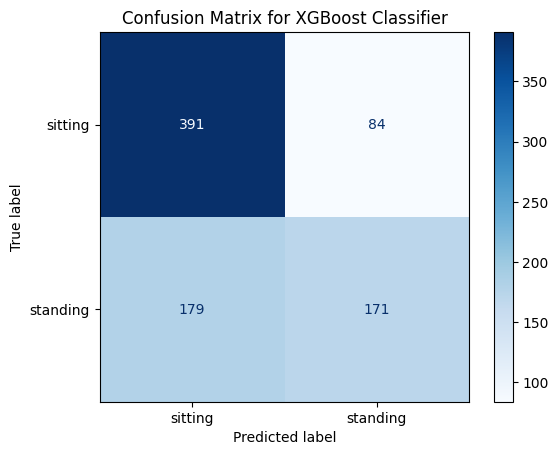

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_y, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")

In [13]:
model = _build_cnn_model(
        arch=arch,
        num_channels=num_channels,
        num_classes=num_classes,
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout,
        fc_hidden=fc_hidden,
    ).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {arch}, Parameters: {count_parameters(model)}")

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Model: skip_concat, Parameters: 25090



=== TRAINING START ===


epoch 1/20, train_loss=0.5767, val_loss=0.8008


epoch 2/20, train_loss=0.4943, val_loss=1.0096


epoch 3/20, train_loss=0.4383, val_loss=0.9724


epoch 4/20, train_loss=0.4112, val_loss=0.6327


...

epoch 16/20, train_loss=0.2359, val_loss=1.1825


epoch 17/20, train_loss=0.2152, val_loss=0.9779


epoch 18/20, train_loss=0.2299, val_loss=0.8312


epoch 19/20, train_loss=0.2342, val_loss=1.6295


epoch 20/20, train_loss=0.2370, val_loss=0.9133

=== WINDOW-LEVEL PERFORMANCE ===
              precision    recall  f1-score   support

     sitting       0.71      0.64      0.67       475
    standing       0.57      0.65      0.61       350

    accuracy                           0.64       825
   macro avg       0.64      0.64      0.64       825
weighted avg       0.65      0.64      0.65       825

window-level accuracy: 0.6436
window-level balanced accuracy: 0.6447


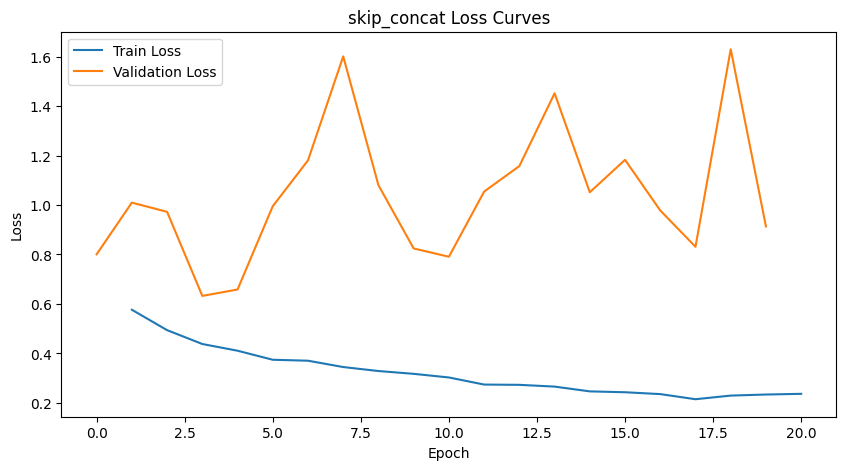

In [14]:
train_loss_history = []
val_loss_history = []
print("\n=== TRAINING START ===")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss_history.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item()

    val_loss_history.append(val_loss / len(test_loader))
    print(f"epoch {epoch+1}/{epochs}, train_loss={total_loss / len(train_loader):.4f}, val_loss={val_loss / len(test_loader):.4f}")
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{arch} Loss Curves")
plt.legend()
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

acc_window = accuracy_score(all_true, all_preds)
bal_acc_window = balanced_accuracy_score(all_true, all_preds)
print("\n=== WINDOW-LEVEL PERFORMANCE ===")
report_labels = list(range(num_classes))
print(
    classification_report(
        all_true,
        all_preds,
        labels=report_labels,
        target_names=le.classes_,
        zero_division=0,
    )
)
print(f"window-level accuracy: {acc_window:.4f}")
print(f"window-level balanced accuracy: {bal_acc_window:.4f}")

Text(0.5, 1.0, 'Confusion Matrix for XGBoost Classifier')

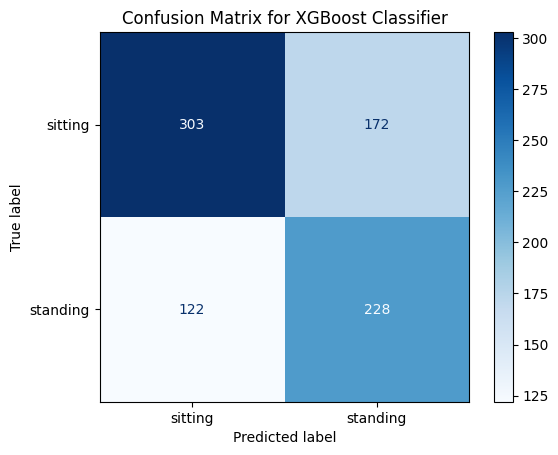

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")